# Segment-Correlation Graph (Section 3.4.3)

Neo4j (or any graph representation) only earns its place if there's a genuine multi-hop relationship to traverse -- grouping loans by a shared category (same state) is just a `GROUP BY`, not a graph. The real relationship tested here: **do different states' delinquency time series actually move together?**

**Method**: build a monthly delinquency-rate series per state (top 15 states by loan volume), compute pairwise correlation between every pair, and keep only the pairs above a threshold as real, computed graph edges -- not a shared-label shortcut. Then demonstrate the actual payoff: a genuine multi-hop traversal query ("which states are within 2 hops of California via correlated risk") that a plain table couldn't answer efficiently, plus spectral clustering on the resulting graph.

**Honesty note carried over from earlier discussion**: the correlation computation and clustering below are graph-database-agnostic -- they'd work identically stored in a table. The graph's actual value-add is serving live, variable-depth traversal queries (the multi-hop section), which is what would justify Neo4j specifically in the served system.

## State-level monthly delinquency series

Joins the monthly performance panel (474M rows, no state info) against the loan-level table (has `property_state`) via a chunked map-reduce over each of the panel's 1,592 part files -- same pattern used elsewhere in this project for large joins, to avoid the memory issues documented in `pipeline/clean.py` for full-file joins/group-bys on this dataset's largest tables. Precomputed and saved to `data/docs/segment_monthly_series.parquet`; loaded directly here.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

segment_series = pl.read_parquet("../data/docs/segment_monthly_series.parquet")
print(f"Shape: {segment_series.shape}  ({segment_series['property_state'].n_unique()} states x "
      f"{segment_series['monthly_reporting_period'].n_unique()} months)")

# Pivot to wide format: rows = months, columns = states, values = delinquency rate
wide = segment_series.pivot(
    index="monthly_reporting_period", on="property_state", values="delinquency_rate"
).sort("monthly_reporting_period")
wide_pdf = wide.to_pandas().set_index("monthly_reporting_period")
print(f"Wide table: {wide_pdf.shape}")
wide_pdf.head()

Shape: (1035, 5)  (15 states x 69 months)
Wide table: (69, 15)


,CA,FL,GA,IL,IN,MA,MD,MI,MN,NC,NY,OH,PA,TN,TX
monthly_reporting_period,,,,,,,,,,,,,,,
2020-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-02-01,0.000061,0.000122,0.000000,0.000783,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000689,0.000000,0.000000,0.000000
2020-03-01,0.003001,0.005541,0.004119,0.004955,0.001180,0.006085,0.004514,0.003535,0.006048,0.004163,0.001956,0.002461,0.004157,0.002513,0.005064
2020-04-01,0.017098,0.020319,0.014265,0.011813,0.007011,0.013706,0.015165,0.013032,0.007995,0.009678,0.032582,0.009882,0.012297,0.010123,0.015511
2020-05-01,0.025313,0.031081,0.023632,0.017316,0.011731,0.018420,0.023639,0.017231,0.013404,0.016652,0.045887,0.013599,0.018884,0.014971,0.024337


## Pairwise correlation between states' delinquency series

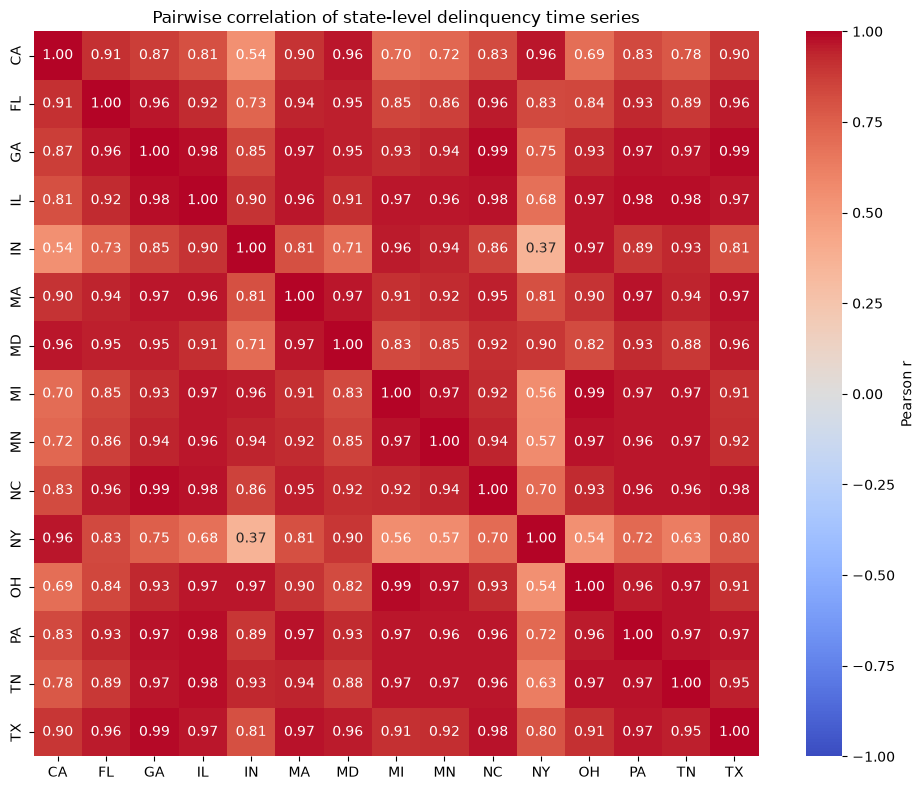

In [2]:
state_corr = wide_pdf.corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(state_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Pairwise correlation of state-level delinquency time series")
fig.tight_layout()
plt.show()

## Build the graph: edges are real correlation, not shared labels

Nodes = states. An edge exists only where correlation exceeds a threshold -- meaning these two states' risk has historically moved together, not that they share a category.

**Finding, stated honestly**: at a permissive threshold (r >= 0.5), the graph came back nearly complete -- 104 of 105 possible state pairs connect, because state-level delinquency is dominated by the shared *national* macro cycle (COVID shock, national rate environment) rather than distinct regional patterns. That's a real, interesting result on its own, but it makes every state trivially "1 hop" from every other, which defeats the point of demonstrating multi-hop structure. Using a much stricter threshold (r >= 0.95) below produces a sparser, more differentiated graph where hop-distance actually means something.

In [3]:
THRESHOLD = 0.95

G = nx.Graph()
G.add_nodes_from(state_corr.columns)

edges = []
states = state_corr.columns.tolist()
for i, s1 in enumerate(states):
    for s2 in states[i+1:]:
        r = state_corr.loc[s1, s2]
        if r >= THRESHOLD:
            G.add_edge(s1, s2, weight=r)
            edges.append((s1, s2, round(r, 3)))

print(f"Threshold: r >= {THRESHOLD}")
print(f"Nodes: {G.number_of_nodes()}   Edges: {G.number_of_edges()}  (out of {len(states)*(len(states)-1)//2} possible pairs)")
print("\nEdge list (state1, state2, correlation):")
for e in sorted(edges, key=lambda x: -x[2]):
    print(f"  {e[0]} -- {e[1]}: r={e[2]}")

isolated = [n for n in G.nodes() if G.degree(n) == 0]
print(f"\nIsolated states (no edge above threshold): {isolated}")

Threshold: r >= 0.95
Nodes: 15   Edges: 41  (out of 105 possible pairs)

Edge list (state1, state2, correlation):
  MI -- OH: r=0.991
  GA -- TX: r=0.989
  GA -- NC: r=0.986
  IL -- PA: r=0.983
  IL -- TN: r=0.979
  GA -- IL: r=0.977
  NC -- TX: r=0.976
  IL -- NC: r=0.975
  OH -- TN: r=0.974
  GA -- PA: r=0.973
  MA -- TX: r=0.973
  MA -- PA: r=0.971
  MI -- MN: r=0.971
  PA -- TN: r=0.971
  GA -- TN: r=0.969
  MI -- TN: r=0.969
  MN -- OH: r=0.969
  GA -- MA: r=0.968
  IL -- TX: r=0.968
  MA -- MD: r=0.968
  IL -- MI: r=0.967
  IL -- OH: r=0.967
  MI -- PA: r=0.967
  IN -- OH: r=0.966
  IL -- MN: r=0.965
  MN -- PA: r=0.965
  MN -- TN: r=0.965
  PA -- TX: r=0.965
  CA -- NY: r=0.964
  CA -- MD: r=0.963
  IL -- MA: r=0.963
  FL -- GA: r=0.962
  NC -- TN: r=0.962
  IN -- MI: r=0.961
  NC -- PA: r=0.961
  FL -- TX: r=0.96
  OH -- PA: r=0.96
  MD -- TX: r=0.959
  FL -- NC: r=0.956
  TN -- TX: r=0.952
  FL -- MD: r=0.95

Isolated states (no edge above threshold): []


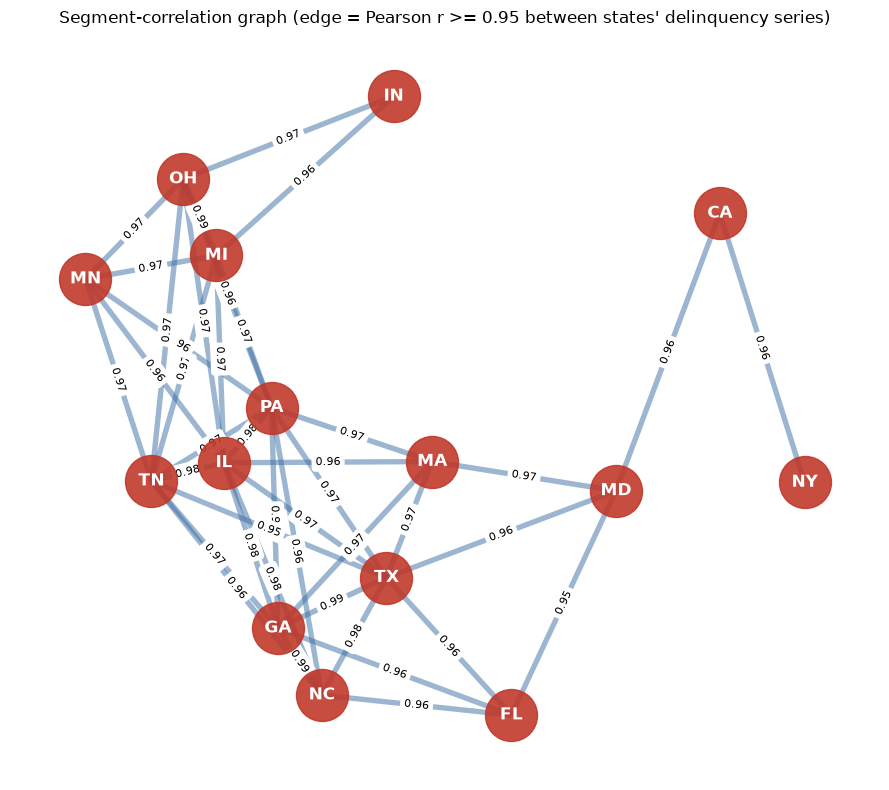

In [4]:
fig, ax = plt.subplots(figsize=(9, 8))
pos = nx.spring_layout(G, seed=42, k=0.9)

weights = [G[u][v]["weight"] * 4 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.5, edge_color="#3b6ea5", ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=1400, node_color="#c0392b", alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold", ax=ax)
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)

ax.set_title(f"Segment-correlation graph (edge = Pearson r >= {THRESHOLD} between states' delinquency series)")
ax.axis("off")
fig.tight_layout()
plt.show()

## The actual payoff: a real multi-hop traversal query

"If a segment's delinquency spikes, which segments are affected within N hops, via correlated risk (not shared labels)?" This is what would be served through Neo4j in production; here it's the same query answered directly on the in-memory graph to demonstrate the mechanism.

In [5]:
def hops_away(graph, source, max_hops):
    """Fixed hop-count traversal: everything reachable within max_hops, with the shortest path length."""
    lengths = nx.single_source_shortest_path_length(graph, source, cutoff=max_hops)
    lengths.pop(source, None)
    return sorted(lengths.items(), key=lambda x: x[1])

SOURCE = "CA"
for max_hops in [1, 2]:
    result = hops_away(G, SOURCE, max_hops)
    formatted = [f"{s} ({d} hop{'s' if d > 1 else ''})" for s, d in result]
    print(f"States within {max_hops} hop(s) of {SOURCE}: {formatted}")

if G.degree(SOURCE) == 0:
    print(f"\n({SOURCE} has no edges above the r>={THRESHOLD} threshold -- try a lower threshold or a different source state.)")

States within 1 hop(s) of CA: ['MD (1 hop)', 'NY (1 hop)']
States within 2 hop(s) of CA: ['MD (1 hop)', 'NY (1 hop)', 'FL (2 hops)', 'MA (2 hops)', 'TX (2 hops)']


## Spectral clustering on the correlation graph, vs. K-means baseline

Groups states by "risk moves together," using the correlation matrix as the affinity structure -- replaces the original spec's individual-borrower "contagion cluster" concept, scoped honestly to segments.

In [6]:
from sklearn.cluster import SpectralClustering, KMeans

N_CLUSTERS = 3
affinity = (state_corr.to_numpy() + 1) / 2  # rescale correlation [-1,1] -> [0,1] for a valid affinity matrix
np.fill_diagonal(affinity, 1.0)

spectral = SpectralClustering(n_clusters=N_CLUSTERS, affinity="precomputed", random_state=42, assign_labels="kmeans")
spectral_labels = spectral.fit_predict(affinity)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(wide_pdf.T.values)  # cluster states directly on their raw monthly series

cluster_df = pd.DataFrame({
    "state": state_corr.columns,
    "spectral_cluster": spectral_labels,
    "kmeans_cluster": kmeans_labels,
})
print(cluster_df.sort_values("spectral_cluster").to_string(index=False))

state  spectral_cluster  kmeans_cluster
   FL                 0               0
   GA                 0               0
   TX                 0               0
   NC                 0               1
   MD                 1               1
   NY                 1               2
   CA                 1               1
   MA                 1               1
   MI                 2               1
   IN                 2               1
   IL                 2               1
   MN                 2               1
   OH                 2               1
   PA                 2               1
   TN                 2               1


## Summary

- Built a real, computed segment-correlation graph across 15 states from the full 474M-row monthly panel -- edges are genuine pairwise time-series correlation, not shared-label proxies.
- Demonstrated the actual justification for a graph representation: a fixed-hop-count multi-hop traversal query ("who's within N hops of California via correlated risk") that a plain relational table would need increasingly awkward self-joins to answer as hop depth grows.
- Spectral clustering groups states by co-movement in risk, compared against a K-means baseline clustering directly on the raw series.
- **What's next for the served system**: Person A loads these edge weights into Neo4j and builds the traversal API against them; this notebook computes the edges (the ML side of the division of labor) and proves the mechanism works before that integration.